# End-to-end resolved lensed-quasar simulation
This notebook connects the package layers into one scientific workflow. It solves a four-image macro lens, derives each image's local convergence/shear and time delay, draws independent stellar populations, generates sparse dynamic IPM maps, evaluates a variable thin disk daily, and samples the resulting resolved light curves with a survey cadence. The CUDA path uses the production-scale $10^7$-ray, $1024^2$ source-map configuration over a full ten years.

In [1]:
import os
from pathlib import Path
import numpy as np
import torch
import caustics
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp
plt.rcParams.update(mcp.publication_style())
OUTPUT_DIRECTORY = Path('end_to_end_output')
OUTPUT_DIRECTORY.mkdir(exist_ok=True)
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available and capabilities.triton_importable
runtime_config = mc.RuntimeConfig(
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda else "auto",
    dtype=torch.float32,
    strict_backend=use_cuda,
)
print(mcp.runtime_description())
lens_redshift, source_redshift = 0.0395, 1.695
macro_lens = caustics.SIE(
    cosmology=caustics.FlatLambdaCDM(), z_l=lens_redshift, z_s=source_redshift,
    x0=0.0, y0=0.0, q=0.72, phi=0.4, Rein=0.9,
)
solutions = mc.solve_caustics_macroimages(
    macro_lens, 0.04, -0.02, initial_grid_size=120, field_of_view_arcsec=2.0
)
for item in solutions:
    print(item.name, f'kappa={item.convergence:.3f}', f'gamma={item.shear:.3f}',
          f'phi_gamma={np.degrees(item.shear_angle_rad):.1f} deg',
          f'delay={item.arrival_time_delay_days:.2f} d')

Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0
A kappa=0.392 gamma=0.392 phi_gamma=30.8 deg delay=0.00 d
B kappa=0.424 gamma=0.424 phi_gamma=11.3 deg delay=0.32 d
C kappa=0.600 gamma=0.600 phi_gamma=-56.5 deg delay=0.50 d
D kappa=0.647 gamma=0.647 phi_gamma=-75.1 deg delay=0.74 d


## Independent dynamic stellar fields
The global lens model fixes each macroimage's local convergence, shear magnitude, and shear direction. We assign 20% of the convergence to a smooth sheet and sample the remaining compact convergence from an illustrative truncated Salpeter distribution with slope 2.35, mean mass 0.3 solar masses, and mass ratio 100. Every image receives an independent seeded stellar and velocity realization in a circular aperture derived from its macro lens, source support, light-loss tolerance, and safety scale. The printed realized compact convergence is allowed to fluctuate around its finite-sample target rather than being silently rescaled.

In [2]:
source_resolution = 1024 if use_cuda else 256
population = mc.StellarPopulation.salpeter(
    mean_mass_solar=0.3,
    mass_ratio=100.0,
    kinematics=mc.SkyProjectedKinematics(
        ra_deg=340.126125, dec_deg=3.358611,
        stellar_dispersion_km_s=170.0,
        peculiar_velocity_dispersion_km_s=235.0,
        include_cmb_dipole=True, seed=0,
    ),
)
print('Stellar population:', population.metadata())


Stellar population: {'name': 'salpeter', 'count_override': None, 'mass_function': {'type': 'PowerLawMassFunction', 'minimum_mass': 0.09697081124093573, 'maximum_mass': 9.697081124093573, 'slope': 2.35}, 'kinematics': {'type': 'SkyProjectedKinematics', 'ra_deg': 340.126125, 'dec_deg': 3.358611, 'stellar_dispersion_km_s': 170.0, 'lens_peculiar_velocity_km_s': None, 'source_peculiar_velocity_km_s': None, 'peculiar_velocity_dispersion_km_s': 235.0, 'omega_matter': 0.3, 'omega_lambda': 0.7, 'seed': 0, 'include_cmb_dipole': True, 'cmb_speed_km_s': 369.82, 'cmb_galactic_longitude_deg': 264.021, 'cmb_galactic_latitude_deg': 48.253, 'lens_redshift': None, 'source_redshift': None}}


## A shared variable relativistic thin disk
The source uses a full-Kerr observer transfer with Q2237-like black-hole and disk parameters in g, r, and i. A reproducible broken-power-law driving signal changes its brightness on a daily grid. The driver is shared by all macroimages, but the macro arrival delay shifts only source evolution. Stellar motion and map epochs remain in observer time. This separation is essential for time-delay work.

C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\relativity\primary.py:223: CompilationWarning: Compilation event 1: preparing a new torch.compile specialization for primary Kerr ray tracing on cuda:0 (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  calculation, execution = _primary_calculation(


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\relativity\coordinates.py:1158: CompilationWarning: Compilation event 2: preparing a new torch.compile specialization for Kerr observer coordinates on cuda:0 (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  solver, execution = _coordinate_solver(


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\relativity\lamppost.py:625: CompilationWarning: Compilation event 3: preparing a new torch.compile specialization for axis-lamppost ray tracing on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  rays = trace_axis_lamppost(


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\sources\reprocessing.py:553: CompilationWarning: Compilation event 4: preparing a new torch.compile specialization for retarded thermal driving on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  temperature4, _ = run_tensor_kernel(


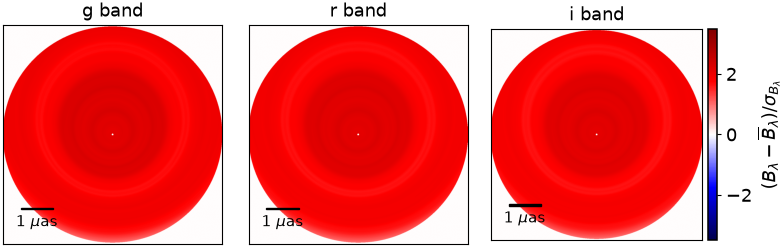

In [3]:
black_hole_mass_solar = 10.0**9.08
spin = 0.74
inclination_deg = 10.0
position_angle_deg = 0.0
trajectory = mc.LinearTrajectory(velocity_uas_per_day=(1.0e-4, 0.5e-4))
driver_times = torch.arange(-100.0, 3651.0)
driver = mc.broken_power_law_driving_signal(
    driver_times, break_timescale_days=200.0, alpha_L=1.0,
    alpha_R=3.0, standard_deviation=0.10, seed=0,
    extrapolation='hold',
)
disk_model = mc.KerrDiskModel(
    black_hole_mass_solar=black_hole_mass_solar,
    eddington_ratio=0.34,
    bands_angstrom={"g": 4770.0, "r": 6231.0, "i": 7625.0},
    spin=spin,
    inclination_deg=inclination_deg,
    position_angle_deg=position_angle_deg,
    source_redshift=source_redshift,
    lamp_fraction=0.1,
    corona_height_above_isco_rg=20.0,
    driving_signal=driver,
    source_grid_shape=source_resolution,
    enclosed_flux_fraction=0.999,
    source_margin=1.05,
    compile_solver=use_cuda,
    lamppost_nalpha=1024 if use_cuda else 256,
    lamppost_radial_bins=512 if use_cuda else 128,
)
source = disk_model.pixelate(runtime=runtime_config)
disk_grid = mc.PlaneGrid(source.geometry.shape, tuple(source.transfer.metadata["source_field_of_view_uas"]))
geometry = source.geometry
rg_m = float(mc.gravitational_radius_m(black_hole_mass_solar))
disk_outer_rg = source.transfer.metadata["disk_outer_rg"]
disk_half_size_rg = disk_outer_rg
isco_rg = float(mc.kerr_isco_radius(spin))

# Use the same streaming temporal standardization as the dedicated GR
# tutorial. No display-only pixel repair or ten-year brightness cube is needed.
display_times = torch.arange(
    0.0, 3650.0 + 12.5, 25.0,
    dtype=torch.float64, device=runtime_config.device,
)
disk_summary = mcp.standardize_source_over_time(
    source, display_times,
    batch_size=4, dtype=torch.float64, device=runtime_config.device,
)
figure, axes = mcp.plot_standardized_source_bands(
    disk_summary, disk_grid, geometry.band_names,
    scale_bar_uas=1.0, figsize=(8.2, 2.7),
)
disk_figure_path = OUTPUT_DIRECTORY / 'end_to_end_relativistic_disk.png'
figure.savefig(disk_figure_path, dpi=220, bbox_inches='tight', facecolor='white')


## Sparse dynamic maps, daily source evolution
Maps are generated every 25 days, while flux is evaluated every day by interpolating the two map-to-source contractions that bracket each epoch. This avoids constructing a daily map cube. The four panels below retain only the first map for inspection. Each is a point-source magnification field in the corresponding macroimage's local lens coordinates.

C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\lens\models.py:842: CompilationWarning: Compilation event 5: preparing a new torch.compile specialization for specular stellar-boundary evolution on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  positions, _ = run_tensor_kernel(


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\solvers\ipm.py:902: CompilationWarning: Compilation event 6: preparing a new Triton specialization for IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(
C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\solvers\ipm.py:1291: CompilationWarning: Compilation event 7: preparing a new Triton specialization for batched IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\sources\reprocessing.py:553: CompilationWarning: Compilation event 8: preparing a new torch.compile specialization for retarded thermal driving on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  temperature4, _ = run_tensor_kernel(
C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\sources\transferred_disk.py:209: CompilationWarning: Compilation event 9: preparing a new Triton specialization for thermal spectral photometry on cuda:0 (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  fast_result = triton_ther

A stars= 2463 realized kappa_*= 0.259
B stars= 5530 realized kappa_*= 0.276
C stars= 6349 realized kappa_*= 0.383
D stars= 3500 realized kappa_*= 0.409


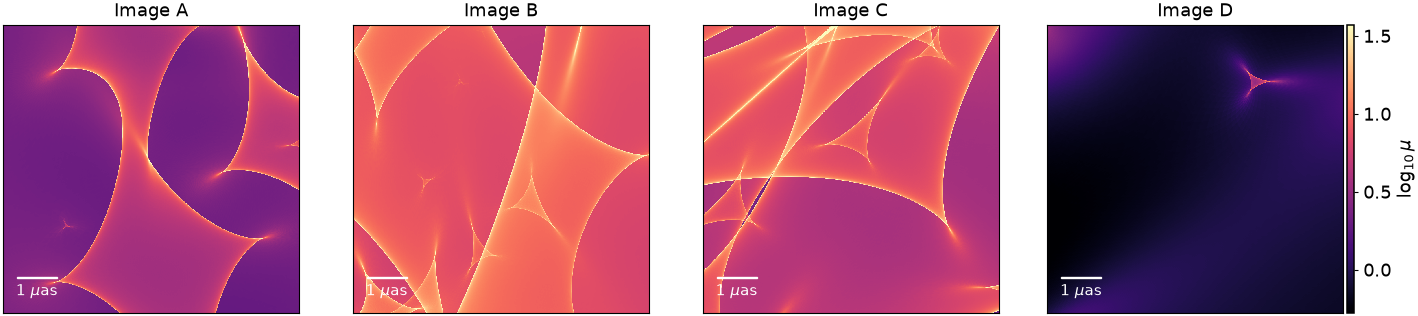

In [4]:
ray_count = 10_000_000 if use_cuda else 262_144
method = mc.production_ipm_config(rays=ray_count)
schedule = mc.production_dynamic_config()
system = mc.MultiImageSystem.from_macroimage_solutions(
    solutions,
    smooth_matter_fraction=0.20,
    lens_redshift=lens_redshift, source_redshift=source_redshift,
    source=source,
    stellar_population=population,
    integration_domain="scout",
    duration_days=3650.0,
    light_loss=0.01,
    safety_scale=1.5,
    seed=0,
    methods=method,
    schedules=schedule,
    trajectories=trajectory,
    runtime=runtime_config,
    caustic_grid_shape=8192,
)
retained_maps = {}

def retain_first(name):
    def observer(index, product):
        if index == 0:
            retained_maps[name] = product
    return observer

map_times = torch.arange(0.0, 3650.0 + 12.5, 25.0)
flux_times = torch.arange(0.0, 3650.0 + 0.5, 1.0)
curves = system.light_curves(
    duration_days=3650, map_cadence_days=25, source_cadence_days=1,
    map_observers={name: retain_first(name) for name in system.image_names},
)
for name in system.image_names:
    realized = system.image(name).realize()
    print(name, 'stars=', len(realized.stars), 'realized kappa_*=', f'{mc.compact_convergence(realized.stars, realized.stellar_aperture.bounding_region):.3f}')
map_logs = [
    np.log10(np.clip(retained_maps[name].numpy(), 1.0e-12, None))
    for name in system.image_names
]
map_finite = np.concatenate([values[np.isfinite(values)] for values in map_logs])
map_vmin, map_vmax = np.quantile(map_finite, (0.002, 0.998))
figure, axes = plt.subplots(1, 4, figsize=(14.8, 3.4))
for ax, name in zip(axes, system.image_names, strict=True):
    mcp.plot_magnification_map(
        retained_maps[name], ax=ax, colorbar=False, title=f"Image {name}",
        scale_bar_uas=1.0, show_axes=False, vmin=map_vmin, vmax=map_vmax,
    )
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
mcp.panel_colorbar(
    figure, axes[-1], axes[-1].images[0], label=r"$\log_{10}\mu$",
    size="2.5%", pad=0.035,
)
figure.tight_layout()


## Resolved truth and mock survey data
The truth panels use the disk model's physical Jy flux density and show i-band AB magnitudes. Differences between rows combine the macro delay, distinct microlensing fields, and the parity-dependent local lens. The observation panels then sample each truth curve with alternating g/r/i visits and Rubin-like depth-dependent error bars.

Using Rubin OpSim WFD cadence: baseline_v4.3.5_10yrs.db


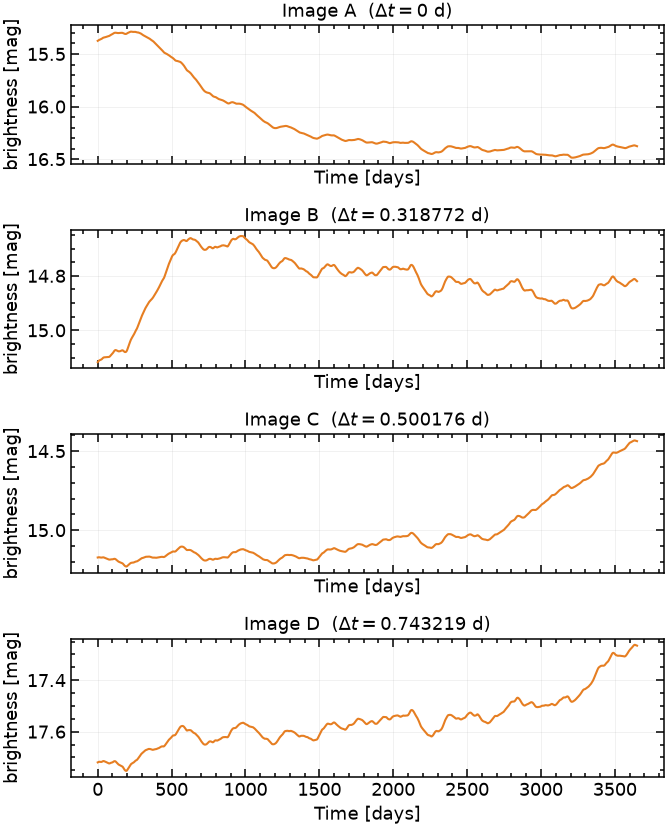

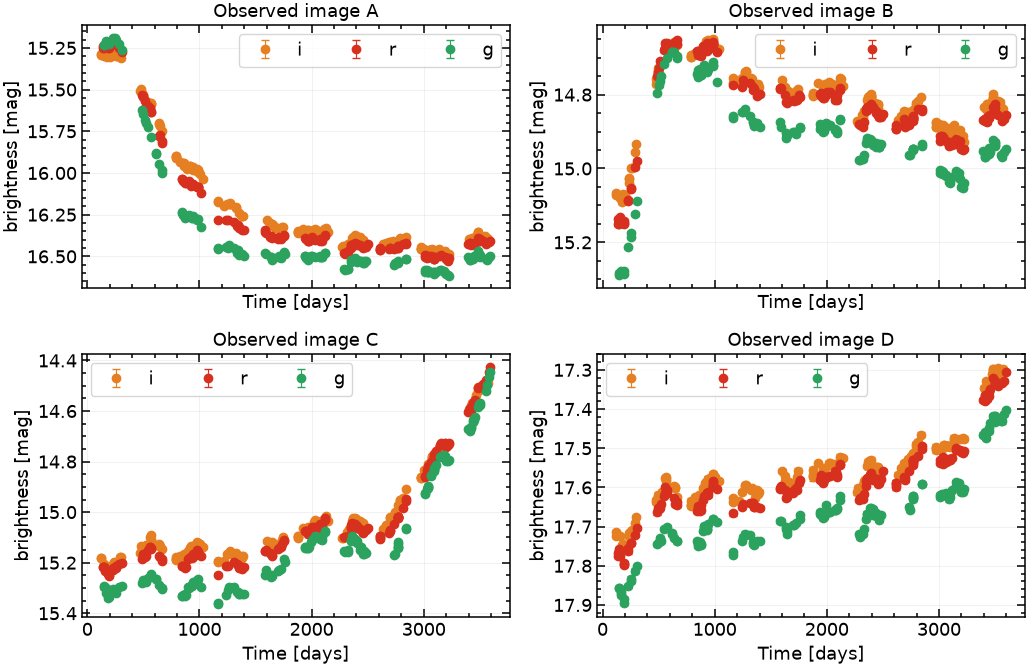

In [5]:
mcp.plot_multi_image_light_curves(
    curves,
    band="i",
    magnitude=True,
    normalize=False,
)
opsim_path = mc.find_rubin_opsim_database()
if opsim_path is not None:
    rubin = mc.RubinOpSimCadenceIndex.from_database(opsim_path)
    cadence = rubin.sample(seed=0, survey="wfd", duration_days=3650.0)
    cadence = cadence.select_bands(geometry.band_names)
    print("Using Rubin OpSim WFD cadence:", opsim_path.name)
else:
    visit_times = np.arange(2.0, 3650.0, 5.0)
    visit_bands = tuple(("g", "r", "i")[index % 3] for index in range(len(visit_times)))
    cadence = mc.SurveyCadence(visit_times, visit_bands, np.full(len(visit_times), 24.5))
    print("No OpSim database found; using the deterministic fallback cadence.")
observations = mc.observe_multi_image_light_curves(
    curves, cadence, seed=0
)
figure, axes = plt.subplots(2, 2, figsize=(10.5, 7.0), sharex=True)
for ax, name in zip(axes.flat, system.image_names, strict=True):
    mcp.plot_photometric_observations(
        observations, image=name, ax=ax, marker_size=6.0, capsize=3.0
    )
figure.tight_layout()

## Moving from tutorial to production
Increase the explicit lens field until the desired compact population and guard region are covered. Use the required source-map field and pixel resolution. Raise the IPM ray budget as needed (for example, 10 million rays with k=2, r=2, v=4 is a conservative high-accuracy choice). Tune temporal batches and spatial chunks on the target GPU. And validate map cadence, far-field settings, and label resolution for the chosen source. Use `benchmark_callable` to report first-call and warmed timings separately.